# Stitched waterfall: 29_n15 `Optimal`, $\ell=1$ only — **four segments**

`l=1` is the one charge acquired over four overlapping segments, out to ~85 mm:

`data/focusing_images/7-27-26/29_n15/Optimal/<range>/l=1/`

| segment | frames | `positions.csv` | nominal start |
|---|---|---|---|
| `0mm-25mm`  | 51 | 0 → 25 mm | 0 mm |
| `20mm-45mm` | 51 | 0 → 25 mm | 20 mm |
| `40mm-65mm` | 51 | 0 → 25 mm | 40 mm |
| `60mm-85mm` | 51 | 0 → 25 mm | 60 mm |

Every `positions.csv` is *local* (each restarts at 0), so global $z$ = `local_z + start`.
Starts are set by hand in `STARTS_MM` — absolute, so tuning one seam does not drag the others.

Same pipeline as the 3-segment notebook (centroid track → transverse slice → resample onto one
global grid → blend), just with the $\ell$ loop removed. Outputs go to
`outputs/waterfall_l1_4seg/`.

In [1]:
from __future__ import annotations

import re
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image


def find_repo_root(start: Path | None = None) -> Path:
    here = (start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError(f"no pyproject.toml at or above {here}")


REPO_ROOT = find_repo_root()
OPTIMAL_ROOT = REPO_ROOT / "data" / "focusing_images" / "7-27-26" / "29_n15" / "Optimal"
OUT_ROOT = REPO_ROOT / "outputs" / "waterfall_l1_4seg"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

ELL = 1
RUN_LABEL = "29_n15_Optimal_7-27-26_l1"

# segment label -> folder + nominal global start (mm), in chain order
SEGMENTS = {
    "0-25":  {"dir": OPTIMAL_ROOT / "0mm-25mm",  "nominal_start_mm":  0.0},
    "20-45": {"dir": OPTIMAL_ROOT / "20mm-45mm", "nominal_start_mm": 20.0},
    "40-65": {"dir": OPTIMAL_ROOT / "40mm-65mm", "nominal_start_mm": 40.0},
    "60-85": {"dir": OPTIMAL_ROOT / "60mm-85mm", "nominal_start_mm": 60.0},
}
SEG_LABELS = list(SEGMENTS)
SEG_REF = SEG_LABELS[0]          # pinned at 0: global z == local z
SEAMS = list(zip(SEG_LABELS[:-1], SEG_LABELS[1:]))

STEP_MM = 0.5

# slicing / centroid knobs, verbatim from the base notebook
SLICE_AXIS = "x"
N_LINES_AVG = 1
TRACK_CENTRE_PER_FRAME = True
CENTER_TRANSVERSE = True
CROP_HALF_WIDTH = 200
BG_BORDER = 50
THRESH_FRAC = 0.10
WINDOW_RADIUS = 200

for lbl, info in SEGMENTS.items():
    assert (info["dir"] / f"l={ELL}").is_dir(), f"missing {info['dir'].name}/l={ELL}"

print(f"repo root : {REPO_ROOT}")
print(f"figures   : {OUT_ROOT.relative_to(REPO_ROOT)}")
print(f"l={ELL}, {len(SEGMENTS)} segments: {' -> '.join(SEG_LABELS)}")

repo root : /home/lukas/Documents/PhD/0_Projects/06_OAM_Focusing/carrie_work/Optimal_Focusing
figures   : outputs/waterfall_l1_4seg
l=1, 4 segments: 0-25 -> 20-45 -> 40-65 -> 60-85


## Loading, background, centroid

In [2]:
INDEX_RE = re.compile(r"_(\d+)\.tif$", re.IGNORECASE)


def frame_index(path: Path) -> int:
    m = INDEX_RE.search(path.name)
    if m is None:
        raise ValueError(f"cannot parse a frame index from {path.name}")
    return int(m.group(1))


def frame_paths(directory: Path) -> list[Path]:
    return sorted((p for p in directory.glob("*.tif") if not p.name.startswith(".")),
                  key=frame_index)


def load_local_positions(directory: Path, paths: list[Path]) -> np.ndarray:
    """Local z (mm) from positions.csv, falling back to index * STEP_MM."""
    csv = directory / "positions.csv"
    if csv.is_file():
        by_name = dict(zip(*pd.read_csv(csv)[["image", "position_mm"]].values.T))
        if all(p.name in by_name for p in paths):
            return np.array([float(by_name[p.name]) for p in paths])
    print(f"  ! {directory.parent.name}: unusable positions.csv — inferring z = index * {STEP_MM} mm")
    return np.array([frame_index(p) * STEP_MM for p in paths])


def load_frames(paths: list[Path]) -> np.ndarray:
    first = np.asarray(Image.open(paths[0]), dtype=np.float32)
    frames = np.empty((len(paths), *first.shape), dtype=np.float32)
    frames[0] = first
    for i, path in enumerate(paths[1:], start=1):
        frame = np.asarray(Image.open(path), dtype=np.float32)
        if frame.shape != first.shape:
            raise ValueError(f"{path.name} is {frame.shape}, expected {first.shape}")
        frames[i] = frame
    return frames


def background_level(frame: np.ndarray, border: int = BG_BORDER) -> float:
    edges = np.concatenate([
        frame[:border, :].ravel(), frame[-border:, :].ravel(),
        frame[:, :border].ravel(), frame[:, -border:].ravel(),
    ])
    return float(np.median(edges))


def _centroid(weights: np.ndarray) -> tuple[float, float]:
    total = weights.sum()
    if total <= 0:
        raise ValueError("no signal above threshold")
    rows = np.arange(weights.shape[0])[:, None]
    cols = np.arange(weights.shape[1])[None, :]
    return float((weights * rows).sum() / total), float((weights * cols).sum() / total)


def find_centroid(frame: np.ndarray) -> tuple[float, float, float]:
    signal = np.clip(frame - background_level(frame), 0, None)
    weights = np.where(signal >= THRESH_FRAC * signal.max(), signal, 0.0)
    cy, cx = _centroid(weights)
    if WINDOW_RADIUS is not None:
        r0 = max(int(round(cy)) - WINDOW_RADIUS, 0)
        c0 = max(int(round(cx)) - WINDOW_RADIUS, 0)
        window = weights[r0:r0 + 2 * WINDOW_RADIUS, c0:c0 + 2 * WINDOW_RADIUS]
        dy, dx = _centroid(window)
        cy, cx = r0 + dy, c0 + dx
    # brightness weight: bright, well-defined in-focus frames dominate the line fit
    return cy, cx, float(signal.max())

## Process each segment into a waterfall on its *local* $z$

Also returns the per-frame transverse RMS width, which is the feature used to place the segments.

In [ ]:
@dataclass
class SegWaterfall:
    seg: str
    nominal_start_mm: float
    waterfall: np.ndarray     # (n_z, n_s), raw bg-subtracted (not peak-normalised)
    s_px: np.ndarray
    z_local: np.ndarray
    centroid_y: np.ndarray          # FITTED straight-line centroid actually used
    centroid_x: np.ndarray
    centroid_y_raw: np.ndarray      # raw per-frame centroid, kept for diagnostics
    centroid_x_raw: np.ndarray
    centroid_w: np.ndarray          # per-frame brightness weight used in the fit
    width_px: np.ndarray      # transverse RMS radius per frame


def _rms_width(profile: np.ndarray, s_px: np.ndarray) -> float:
    w = np.clip(profile, 0, None)
    total = w.sum()
    if total <= 0:
        return np.nan
    mean = (w * s_px).sum() / total
    return float(np.sqrt((w * (s_px - mean) ** 2).sum() / total))


def segment_raw_centroids(label: str):
    """Pass 1: load a segment's frames and return (z_local, centroid_y, centroid_x,
    weight) -- the RAW per-frame centroid and brightness, before the shared line fit."""
    info = SEGMENTS[label]
    directory = info["dir"] / f"l={ELL}"
    paths = frame_paths(directory)
    if not paths:
        raise FileNotFoundError(f"no TIFFs in {directory}")
    z_local = load_local_positions(directory, paths)
    frames = load_frames(paths)
    cen = np.array([find_centroid(f) for f in frames])   # (n, 3): row, col, brightness
    return z_local, cen[:, 0], cen[:, 1], cen[:, 2]


def process_segment(label: str, centroid_y: np.ndarray, centroid_x: np.ndarray,
                    centroid_y_raw: np.ndarray, centroid_x_raw: np.ndarray,
                    centroid_w: np.ndarray) -> SegWaterfall:
    """Pass 2: build one segment's waterfall on the supplied FITTED straight-line
    centroid (no per-frame wobble).  Frames are reloaded here (released after the
    raw-centroid pass) so peak memory stays at a single segment."""
    info = SEGMENTS[label]
    directory = info["dir"] / f"l={ELL}"
    paths = frame_paths(directory)
    z_local = load_local_positions(directory, paths)
    frames = load_frames(paths)

    if SLICE_AXIS == "x":
        cuts, centre_along, centre_across = frames, centroid_y, centroid_x
    else:
        cuts, centre_along, centre_across = frames.transpose(0, 2, 1), centroid_x, centroid_y
    n_lines, length = cuts.shape[1], cuts.shape[2]

    half = N_LINES_AVG // 2
    fixed_line = int(round(centre_along.mean()))
    background = float(np.median([background_level(f) for f in frames]))

    slices = []
    for plane, c_along, c_across in zip(cuts, centre_along, centre_across):
        line = int(round(c_along)) if TRACK_CENTRE_PER_FRAME else fixed_line
        lo = int(np.clip(line - half, 0, n_lines - N_LINES_AVG))
        cut = plane[lo:lo + N_LINES_AVG].mean(axis=0)
        if CENTER_TRANSVERSE:
            cut = np.roll(cut, length // 2 - int(round(c_across)))
        slices.append(cut)

    waterfall = np.clip(np.stack(slices) - background, 0, None)
    del cuts, frames

    s_px = np.arange(length) - (length // 2 if CENTER_TRANSVERSE else 0)
    if CROP_HALF_WIDTH is not None:
        keep = np.abs(s_px) <= CROP_HALF_WIDTH
        waterfall, s_px = waterfall[:, keep], s_px[keep]

    width_px = np.array([_rms_width(row, s_px) for row in waterfall])
    return SegWaterfall(
        seg=label, nominal_start_mm=info["nominal_start_mm"],
        waterfall=waterfall, s_px=s_px, z_local=z_local,
        centroid_y=centroid_y, centroid_x=centroid_x,
        centroid_y_raw=centroid_y_raw, centroid_x_raw=centroid_x_raw, centroid_w=centroid_w,
        width_px=width_px)


# Straight-line centroid: ONE shared slope across the run's segments (each keeps
# its own offset), then build every segment on its fitted line.
#   pass 1: raw per-frame centroid + brightness for every segment
#   fit:    one shared-slope line for both centroid axes
#   pass 2: rebuild each segment on its fitted line (frames reloaded).
from centroid_lines import fit_centroid_lines

raw_sections = {}
for lbl in SEG_LABELS:
    z_local, cy, cx, w = segment_raw_centroids(lbl)
    raw_sections[lbl] = dict(z=z_local, cy=cy, cx=cx, w=w)

lines, (slope_y, slope_x) = fit_centroid_lines(raw_sections)
print(f"shared centroid slope (y, x) = ({slope_y:+.3f}, {slope_x:+.3f}) px/mm\n")

segments = {}
for lbl in SEG_LABELS:
    r = raw_sections[lbl]
    cy_fit, cx_fit = lines[lbl]
    sw = process_segment(lbl, cy_fit, cx_fit, r["cy"], r["cx"], r["w"])
    segments[lbl] = sw
    print(f"{lbl:>6}  {str(sw.waterfall.shape):>12}  "
          f"local z {sw.z_local.min():.1f}..{sw.z_local.max():.1f} mm")


  0-25     (51, 401)  local z 0.0..25.0 mm
 20-45     (51, 401)  local z 0.0..25.0 mm


## Set each segment's global start by hand

Global $z$ = `local_z + STARTS_MM[seg]`; these are **absolute**, so segments tune independently.
The reference segment is pinned at 0. Seeded from the 3-segment notebook's $\ell=1$ values
(24.0, 44.5) with the 4th carried on the same nominal-to-true correction (+4.5 → 64.5).
**Re-tune the last one against the seam zoom below.**

* too **small** → the segment's curve rides **above** its predecessor's;
* too **large** → it drops **below**;
* just right → the curves lie on top of each other across the overlap.

In [ ]:
# EDIT BY HAND. Reference segment stays at 0.0.
STARTS_MM = {
    "0-25":   0.0,
    "20-45": 24.5,
    "40-65": 45.5,
    "60-85": 69.0,   # <- new 4th segment: tune against the seam zoom
}

assert set(STARTS_MM) == set(SEG_LABELS)
assert STARTS_MM[SEG_REF] == 0.0, "the reference segment must stay pinned at 0.0"

NOMINAL_STARTS = {lbl: SEGMENTS[lbl]["nominal_start_mm"] for lbl in SEG_LABELS}


def global_z(sw: SegWaterfall) -> np.ndarray:
    return sw.z_local + STARTS_MM[sw.seg]


for lbl in SEG_LABELS:
    print(f"  {lbl:>6} @ {STARTS_MM[lbl]:6.2f} mm  (nominal {NOMINAL_STARTS[lbl]:.0f})")

    0-25 @   0.00 mm  (nominal 0)
   20-45 @  24.50 mm  (nominal 20)
   40-65 @  45.50 mm  (nominal 40)
   60-85 @  69.00 mm  (nominal 60)


### Check the offsets: do the width curves line up?

All four width traces on global $z$ at the hand-set starts (coloured), with each non-reference
segment at its **nominal** start in faint grey. Dashed lines mark the seams.

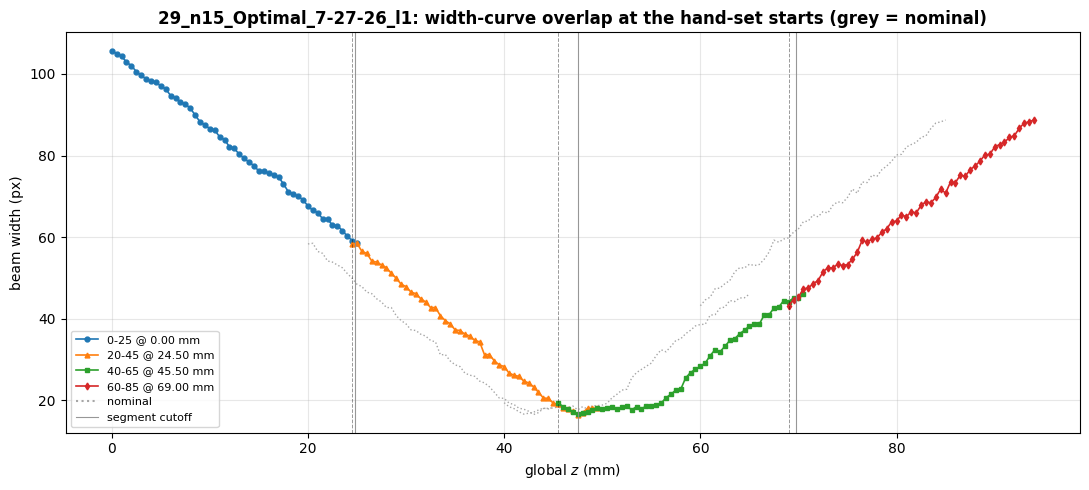

In [ ]:
SEG_COLOURS = {lbl: f"C{i}" for i, lbl in enumerate(SEG_LABELS)}
SEG_MARKERS = dict(zip(SEG_LABELS, ["o-", "^-", "s-", "d-"]))

fig, ax = plt.subplots(figsize=(11, 5))
for lbl in SEG_LABELS:
    sw = segments[lbl]
    if lbl != SEG_REF:
        ax.plot(sw.z_local + NOMINAL_STARTS[lbl], sw.width_px, ":", lw=1, color="0.65", zorder=1)
    ax.plot(global_z(sw), sw.width_px, SEG_MARKERS[lbl], ms=3.5, lw=1.2,
            color=SEG_COLOURS[lbl], zorder=2, label=f"{lbl} @ {STARTS_MM[lbl]:.2f} mm")

for lbl in SEG_LABELS[1:]:
    ax.axvline(STARTS_MM[lbl], color="k", ls="--", lw=0.7, alpha=0.4)
ax.plot([], [], ":", color="0.65", label="nominal")

# thin grey line at each cutoff: the overlap midpoint where the stitch hands over
for i, (left, right) in enumerate(SEAMS):
    zc = 0.5 * (global_z(segments[right])[0] + global_z(segments[left])[-1])
    ax.axvline(zc, color="0.55", lw=0.8, alpha=0.9,
               label="segment cutoff" if i == 0 else None)

ax.set_xlabel("global $z$ (mm)")
ax.set_ylabel("beam width (px)")
ax.set_title(f"{RUN_LABEL}: width-curve overlap at the hand-set starts (grey = nominal)",
             fontweight="bold")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_ROOT / "alignment_diagnostic.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

### Zoom on each of the three seams

One panel per seam, zoomed to the shared band plus a margin. Nudge `STARTS_MM` until the two
curves sit on each other in every panel.

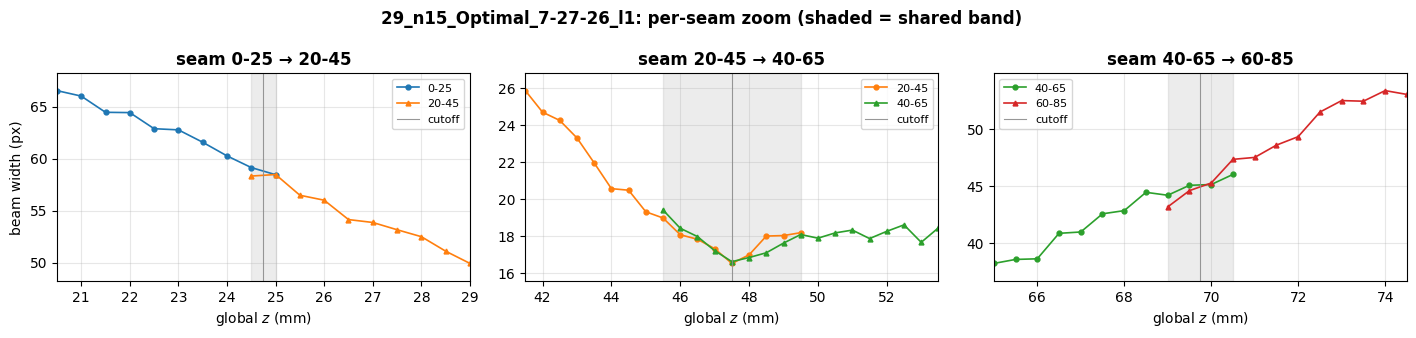

In [ ]:
fig, axes = plt.subplots(1, len(SEAMS), figsize=(4.8 * len(SEAMS), 3.4), squeeze=False)

for ax, (left, right) in zip(axes[0], SEAMS):
    zl, zr = global_z(segments[left]), global_z(segments[right])
    ax.plot(zl, segments[left].width_px, "o-", ms=3.5, lw=1.2, color=SEG_COLOURS[left], label=left)
    ax.plot(zr, segments[right].width_px, "^-", ms=3.5, lw=1.2, color=SEG_COLOURS[right], label=right)

    lo, hi = max(zl[0], zr[0]), min(zl[-1], zr[-1])
    if hi > lo:
        ax.axvspan(lo, hi, color="grey", alpha=0.15)
        ax.set_xlim(lo - 4, hi + 4)
    else:
        ax.set_xlim(min(zl[-1], zr[0]) - 4, max(zl[-1], zr[0]) + 4)
        ax.text(0.5, 0.9, "no overlap!", transform=ax.transAxes, ha="center",
                color="crimson", fontweight="bold")

    # thin grey line at the cutoff: the overlap midpoint where the stitch hands over
    ax.axvline(0.5 * (zr[0] + zl[-1]), color="0.55", lw=0.8, alpha=0.9, label="cutoff")

    band = np.concatenate([
        segments[left].width_px[(zl >= lo - 4) & (zl <= hi + 4)],
        segments[right].width_px[(zr >= lo - 4) & (zr <= hi + 4)],
    ])
    band = band[np.isfinite(band)]
    if band.size:
        pad = 0.1 * (band.max() - band.min() + 1e-9)
        ax.set_ylim(band.min() - pad, band.max() + pad)

    ax.set_title(f"seam {left} → {right}", fontweight="bold")
    ax.set_xlabel("global $z$ (mm)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[0, 0].set_ylabel("beam width (px)")
fig.suptitle(f"{RUN_LABEL}: per-seam zoom (shaded = shared band)", fontweight="bold")
fig.tight_layout()
fig.savefig(OUT_ROOT / "seam_zoom.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

## Stitch onto one global-$z$ grid

Starts are sub-frame values, so segments do not share a sample grid: build one uniform grid at
`STEP_MM` over the union of the placed segments, resample each segment onto it by linear
interpolation in $z$ (column by column), then blend with per-segment weights normalised to sum
to 1 wherever anything is covered.

* **crossfade** — a linear hand-over across each pairwise overlap band; all three seams fade independently.
* **average** — equal weight to every segment covering that $z$.
* **hardcut** — the earlier segment wins up to each overlap midpoint, the later one after.

Peak-normalisation happens **after** stitching, so colours are comparable over the whole span.

In [ ]:
BLEND_MODES = ["crossfade", "average", "hardcut"]


@dataclass
class Stitched:
    mode: str
    waterfall: np.ndarray   # (n_z, n_s) peak-normalised, on the common grid
    s_px: np.ndarray
    z_mm: np.ndarray
    centroid_y: np.ndarray
    centroid_x: np.ndarray
    coverage: np.ndarray    # how many segments cover each row

    @property
    def brightest_z(self) -> float:
        return float(self.z_mm[self.waterfall.max(axis=1).argmax()])


def _resample_map(z_src, water_src, z_grid):
    """Linear-interpolate a (n_z, n_s) map from z_src onto z_grid, per transverse column."""
    covered = (z_grid >= z_src[0] - 1e-9) & (z_grid <= z_src[-1] + 1e-9)
    out = np.zeros((len(z_grid), water_src.shape[1]))
    if covered.any():
        zc = z_grid[covered]
        out[covered] = np.stack(
            [np.interp(zc, z_src, water_src[:, c]) for c in range(water_src.shape[1])], axis=1
        )
    return out, covered


def _blend_weights(mode, z_grid, covers):
    w = {lbl: covers[lbl].astype(float) for lbl in SEG_LABELS}

    if mode != "average":
        for left, right in SEAMS:
            both = covers[left] & covers[right]
            if not both.any():
                continue
            z_ov = z_grid[both]
            lo, hi = z_ov.min(), z_ov.max()
            if mode == "hardcut":
                ramp = (z_ov <= 0.5 * (lo + hi)).astype(float)
            else:  # crossfade
                ramp = np.clip((hi - z_ov) / (hi - lo), 0.0, 1.0) if hi > lo \
                    else np.full(z_ov.shape, 0.5)
            w[left][both] = ramp
            w[right][both] = 1.0 - ramp

    stack = np.stack([w[lbl] for lbl in SEG_LABELS])
    total = stack.sum(axis=0)
    good = total > 0
    stack[:, good] /= total[good]
    return dict(zip(SEG_LABELS, stack))


def stitch(mode: str, z_grid: np.ndarray) -> Stitched:
    s_px = segments[SEG_REF].s_px
    for lbl, sw in segments.items():
        assert np.array_equal(sw.s_px, s_px), f"segment {lbl} cropped to a different extent"

    maps, covers, zs = {}, {}, {}
    for lbl, sw in segments.items():
        z = global_z(sw)
        maps[lbl], covers[lbl] = _resample_map(z, sw.waterfall, z_grid)
        zs[lbl] = z

    weights = _blend_weights(mode, z_grid, covers)
    water = np.zeros_like(maps[SEG_REF])
    for lbl in SEG_LABELS:
        water += weights[lbl][:, None] * maps[lbl]

    covered_any = np.any([covers[lbl] for lbl in SEG_LABELS], axis=0)
    water[~covered_any] = 0.0
    peak = float(water.max())
    if peak > 0:
        water /= peak

    # centroids: first segment in chain order that covers each row
    cy = np.full(z_grid.shape, np.nan)
    cx = np.full(z_grid.shape, np.nan)
    for lbl in SEG_LABELS:
        need = np.isnan(cy) & covers[lbl]
        if need.any():
            cy[need] = np.interp(z_grid[need], zs[lbl], segments[lbl].centroid_y)
            cx[need] = np.interp(z_grid[need], zs[lbl], segments[lbl].centroid_x)

    coverage = np.sum([covers[lbl] for lbl in SEG_LABELS], axis=0)
    return Stitched(mode, water, s_px, z_grid, cy, cx, coverage)


_z_lo = min(global_z(segments[lbl])[0] for lbl in SEG_LABELS)
_z_hi = max(global_z(segments[lbl])[-1] for lbl in SEG_LABELS)
Z_GRID = np.arange(_z_lo, _z_hi + 0.5 * STEP_MM, STEP_MM)

SEAM_BANDS = [(global_z(segments[right])[0], global_z(segments[left])[-1])
              for left, right in SEAMS]


def _hardcut_z(z_grid):
    """Where `hardcut` actually switches segments: the midpoint of each overlap *as seen on the
    grid*, computed exactly as _blend_weights does (grid snapping can move it off the midpoint
    of SEAM_BANDS by up to half a step)."""
    covers = {lbl: (z_grid >= global_z(segments[lbl])[0] - 1e-9)
                   & (z_grid <= global_z(segments[lbl])[-1] + 1e-9) for lbl in SEG_LABELS}
    cuts = []
    for left, right in SEAMS:
        both = covers[left] & covers[right]
        if both.any():
            z_ov = z_grid[both]
            cuts.append(0.5 * (float(z_ov.min()) + float(z_ov.max())))
    return cuts


HARDCUT_Z = _hardcut_z(Z_GRID)

stitched = {mode: stitch(mode, Z_GRID) for mode in BLEND_MODES}

st = stitched["crossfade"]
print(f"stitched -> {st.waterfall.shape}   z {st.z_mm.min():.1f}..{st.z_mm.max():.1f} mm"
      f"   brightest at {st.brightest_z:.1f} mm")
print("seam bands : " + ", ".join(f"{lo:.1f}-{hi:.1f}" for lo, hi in SEAM_BANDS) + " mm")
print("hardcut at : " + ", ".join(f"{z:.2f}" for z in HARDCUT_Z) + " mm")
gaps = int((st.coverage == 0).sum())
if gaps:
    print(f"!! {gaps} grid rows covered by NO segment — check STARTS_MM")

stitched -> (189, 401)   z 0.0..94.0 mm   brightest at 48.0 mm
seam bands : 24.5-25.0, 45.5-49.5, 69.0-70.5 mm
hardcut at : 24.75, 47.50, 69.75 mm


## Compare the three blends

Dashed lines mark the three seam bands. Correctly co-registered, the caustic arms run straight
through every seam with no kink, and even `hardcut` looks seamless.

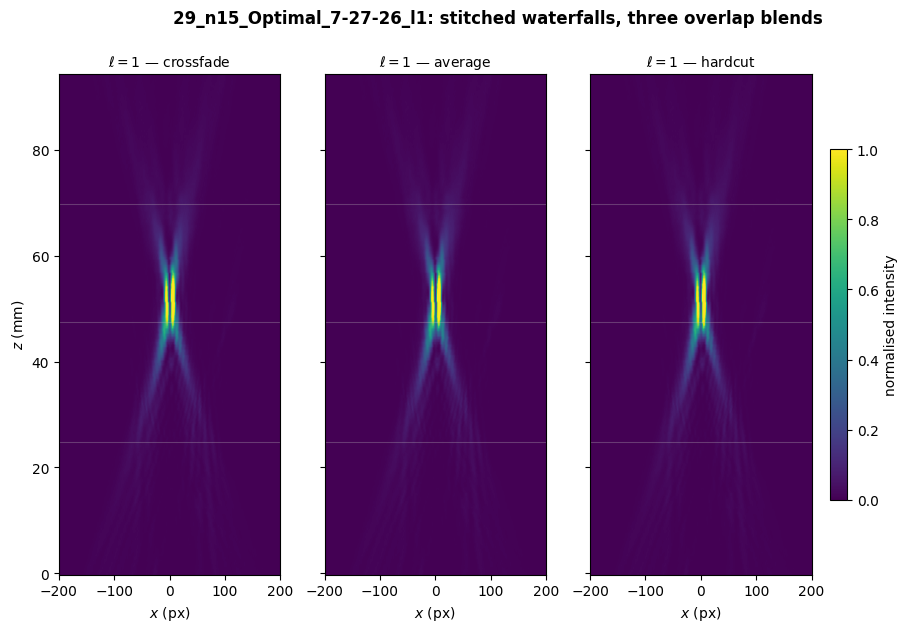

In [ ]:
def draw_waterfall(ax, st, title):
    dz = float(np.median(np.diff(st.z_mm))) if st.z_mm.size > 1 else STEP_MM
    im = ax.imshow(st.waterfall, origin="lower", aspect="auto", cmap="viridis", vmin=0, vmax=1,
                   extent=[st.s_px[0], st.s_px[-1], st.z_mm[0] - dz / 2, st.z_mm[-1] + dz / 2])
    ax.set_xlabel(f"${SLICE_AXIS}$ (px)")
    ax.set_ylabel("$z$ (mm)")
    ax.set_title(title, fontsize=10)
    return im


fig, axes = plt.subplots(1, len(BLEND_MODES), figsize=(3.4 * len(BLEND_MODES) + 1.5, 6.5),
                         sharey=True)
for ax, mode in zip(axes, BLEND_MODES):
    im = draw_waterfall(ax, stitched[mode], f"$\\ell={ELL}$ — {mode}")
    # for lo, hi in SEAM_BANDS:
    #     for y in (lo, hi):
    #         ax.axhline(y, color="w", ls="--", lw=0.7, alpha=0.6)
    # thin grey line at each cutoff: where hardcut switches segments
    for zc in HARDCUT_Z:
        ax.axhline(zc, color="0.75", lw=0.8, alpha=0.3)
for ax in axes[1:]:
    ax.set_ylabel("")

fig.colorbar(im, ax=axes.tolist(), label="normalised intensity", pad=0.02, shrink=0.7)
fig.suptitle(f"{RUN_LABEL}: stitched waterfalls, three overlap blends", fontweight="bold")
fig.savefig(OUT_ROOT / "blend_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

## Final stitched waterfall (chosen blend)

Thin grey lines mark the **segment cutoffs** — the overlap midpoints where `hardcut` hands over
from one segment to the next, so every row above a line comes from a different segment than the
rows below it. A caustic arm that steps across one of these lines is a residual misalignment at
that seam.

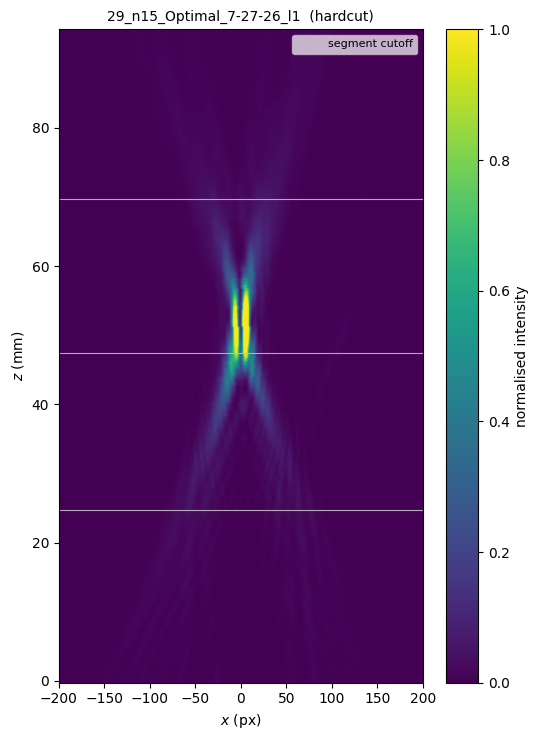

saved to outputs/waterfall_l1_4seg
segment cutoffs at 24.75, 47.50, 69.75 mm


In [ ]:
CHOSEN_BLEND = "hardcut"   # <- set to "crossfade" or "average" after eyeballing the grid above
assert CHOSEN_BLEND in BLEND_MODES

st = stitched[CHOSEN_BLEND]
fig, ax = plt.subplots(figsize=(5.5, 7.5))
im = draw_waterfall(ax, st, f"{RUN_LABEL}  ({CHOSEN_BLEND})")

# thin grey line at each hardcut boundary: where the map switches from one segment to the next
for i, zc in enumerate(HARDCUT_Z):
    ax.axhline(zc, color="0.75", lw=0.8, alpha=0.3,
               label="segment cutoff" if i == 0 else None)
ax.legend(fontsize=8, loc="upper right", framealpha=0.7)

fig.colorbar(im, ax=ax, label="normalised intensity")
fig.tight_layout()
fig.savefig(OUT_ROOT / f"{RUN_LABEL}_{SLICE_AXIS}.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"saved to {OUT_ROOT.relative_to(REPO_ROOT)}")
print("segment cutoffs at " + ", ".join(f"{z:.2f}" for z in HARDCUT_Z) + " mm")

## Beam width across the full stitched scan

Transverse RMS width measured on the **stitched** map — the same feature used for alignment, now
on one continuous scan, so it should run smoothly through all three seams. Shaded bands are the
overlaps; thin grey lines are the **segment cutoffs** where `hardcut` switches segments. A step
in the curve at a grey line is a residual mismatch at that seam. Focus is where the curve
bottoms out.

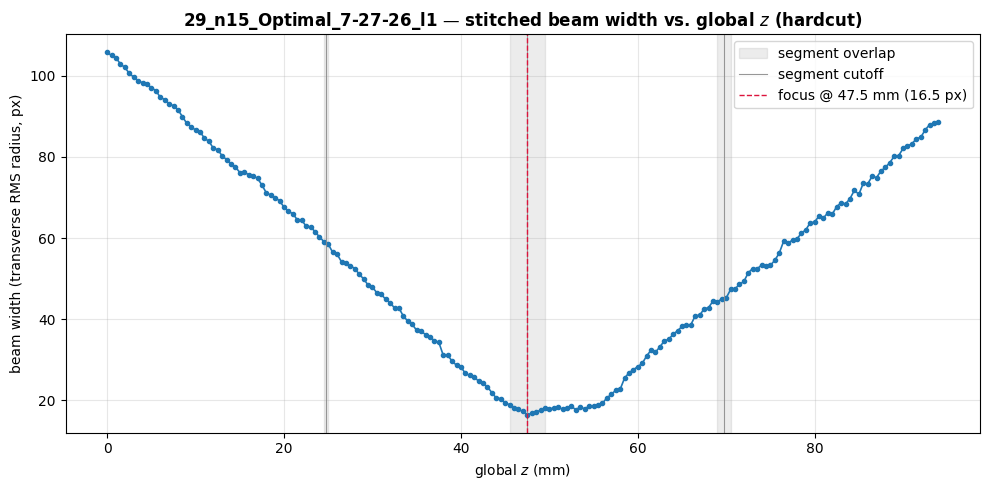

focus at z = 47.50 mm, min width 16.52 px


In [ ]:
width = np.array([_rms_width(row, st.s_px) for row in st.waterfall])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(st.z_mm, width, "o-", ms=3, lw=1.2, color="C0")
for i, (lo, hi) in enumerate(SEAM_BANDS):
    ax.axvspan(lo, hi, color="grey", alpha=0.15, label="segment overlap" if i == 0 else None)

# thin grey line at each hardcut boundary: where the stitch switches segments
for i, zc in enumerate(HARDCUT_Z):
    ax.axvline(zc, color="0.55", lw=0.8, alpha=0.9,
               label="segment cutoff" if i == 0 else None)

ok = np.isfinite(width) & (st.coverage > 0)
z_focus = float(st.z_mm[ok][np.nanargmin(width[ok])])
min_width = float(np.nanmin(width[ok]))
ax.axvline(z_focus, color="crimson", ls="--", lw=1,
           label=f"focus @ {z_focus:.1f} mm ({min_width:.1f} px)")

ax.set_xlabel("global $z$ (mm)")
ax.set_ylabel("beam width (transverse RMS radius, px)")
ax.set_title(f"{RUN_LABEL} — stitched beam width vs. global $z$ ({CHOSEN_BLEND})",
             fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_ROOT / f"{RUN_LABEL}_stitched_width.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"focus at z = {z_focus:.2f} mm, min width {min_width:.2f} px")

## Centroid diagnostic

Beam centroid on the global grid, seams dashed. A jump at a seam means the two segments' beams
sat at different sensor positions — harmless for the centred waterfall, but worth seeing. The
bottom panel is segment coverage (1 = single segment, 2 = inside an overlap, 0 = a gap).

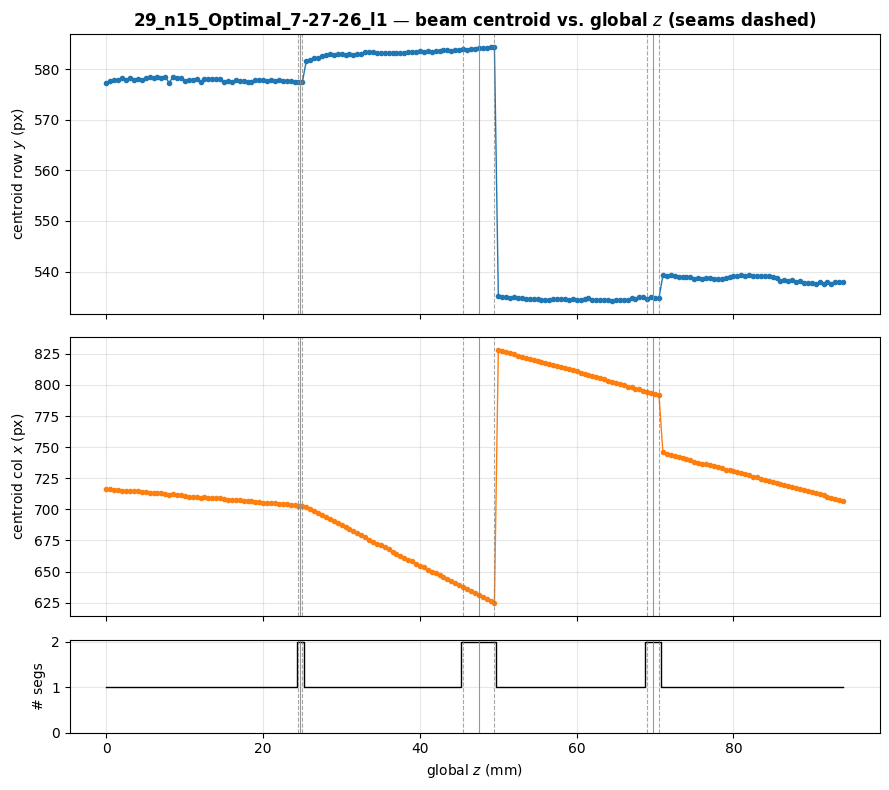

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True,
                         gridspec_kw={"height_ratios": [3, 3, 1]})
axes[0].plot(st.z_mm, st.centroid_y, "o-", ms=3, lw=1, color="C0")
axes[1].plot(st.z_mm, st.centroid_x, "o-", ms=3, lw=1, color="C1")
axes[2].step(st.z_mm, st.coverage, where="mid", color="k", lw=1)
axes[2].set_yticks([0, 1, 2])

for ax in axes:
    for lo, hi in SEAM_BANDS:
        for y in (lo, hi):
            ax.axvline(y, color="grey", ls="--", lw=0.8, alpha=0.7)
    # thin grey line at each cutoff: where the stitch switches segments
    for zc in HARDCUT_Z:
        ax.axvline(zc, color="0.55", lw=0.8, alpha=0.9)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("centroid row $y$ (px)")
axes[1].set_ylabel("centroid col $x$ (px)")
axes[2].set_ylabel("# segs")
axes[2].set_xlabel("global $z$ (mm)")
axes[0].set_title(f"{RUN_LABEL} — beam centroid vs. global $z$ (seams dashed)", fontweight="bold")
fig.tight_layout()
fig.savefig(OUT_ROOT / f"{RUN_LABEL}_centroids.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

## Summary

In [ ]:
summary = pd.DataFrame([{
    "run": RUN_LABEL,
    "ell": ELL,
    "blend": CHOSEN_BLEND,
    "n_segments": len(SEG_LABELS),
    "n_rows": st.z_mm.size,
    "z_min_mm": st.z_mm.min(),
    "z_max_mm": st.z_mm.max(),
    "z_focus_mm": z_focus,
    "min_width_px": min_width,
    "brightest_z_mm": st.brightest_z,
    **{f"start_{lbl}_mm": round(STARTS_MM[lbl], 2) for lbl in SEG_LABELS},
}]).round(2)

summary.to_csv(OUT_ROOT / f"{RUN_LABEL}_summary.csv", index=False)
display(summary.T.rename(columns={0: "value"}))
print(f"saved {RUN_LABEL}_summary.csv")

,value
run,29_n15_Optimal_7-27-26_l1
ell,1
blend,hardcut
n_segments,4
n_rows,189
z_min_mm,0.0
z_max_mm,94.0
z_focus_mm,47.5
min_width_px,16.52
brightest_z_mm,47.5


saved 29_n15_Optimal_7-27-26_l1_summary.csv
